In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/student-mat.csv', sep=';')

# Create pass/fail target column
df['pass'] = (df['G3'] >= 10).astype(int)

print("Shape:", df.shape)
print("\nPass/Fail count:")
print(df['pass'].value_counts())
print("\nPass rate:", round(df['pass'].mean() * 100, 1), "%")

Shape: (395, 34)

Pass/Fail count:
pass
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1 %


In [5]:
# Check data types and null values
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Null Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics (numeric columns) ===")
print(df.describe().round(2))

=== Data Types ===
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
pass          int64
dtype: object

=== Null Values ===
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup    

In [6]:
import os

# Create folders if they don't exist
os.makedirs('../outputs/figures', exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


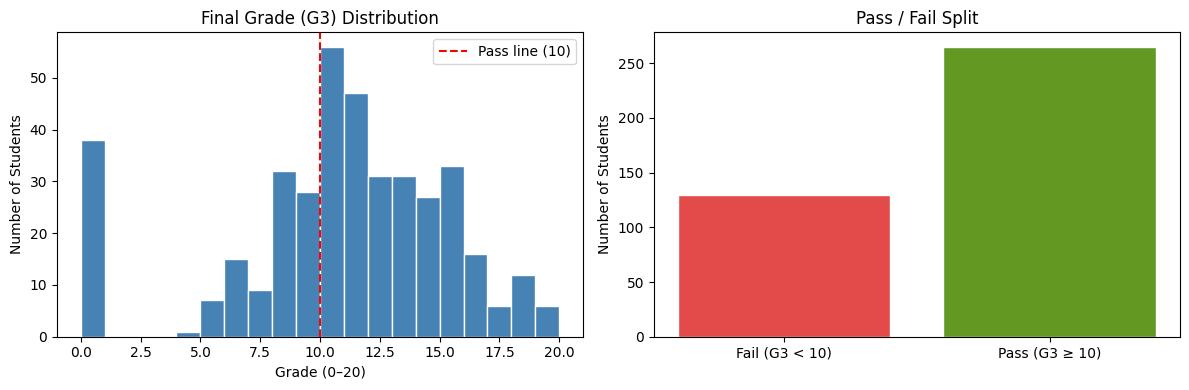

Saved to outputs/figures/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# G3 raw grade distribution
axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Final Grade (G3) Distribution')
axes[0].set_xlabel('Grade (0–20)')
axes[0].set_ylabel('Number of Students')
axes[0].axvline(x=10, color='red', linestyle='--', label='Pass line (10)')
axes[0].legend()

# Pass vs Fail count
axes[1].bar(['Fail (G3 < 10)', 'Pass (G3 ≥ 10)'],
            df['pass'].value_counts().sort_index().values,
            color=['#E24B4A', '#639922'], edgecolor='white')
axes[1].set_title('Pass / Fail Split')
axes[1].set_ylabel('Number of Students')

plt.tight_layout()
plt.savefig('../outputs/figures/grade_distribution.png', dpi=150)
plt.show()
print("Saved to outputs/figures/")

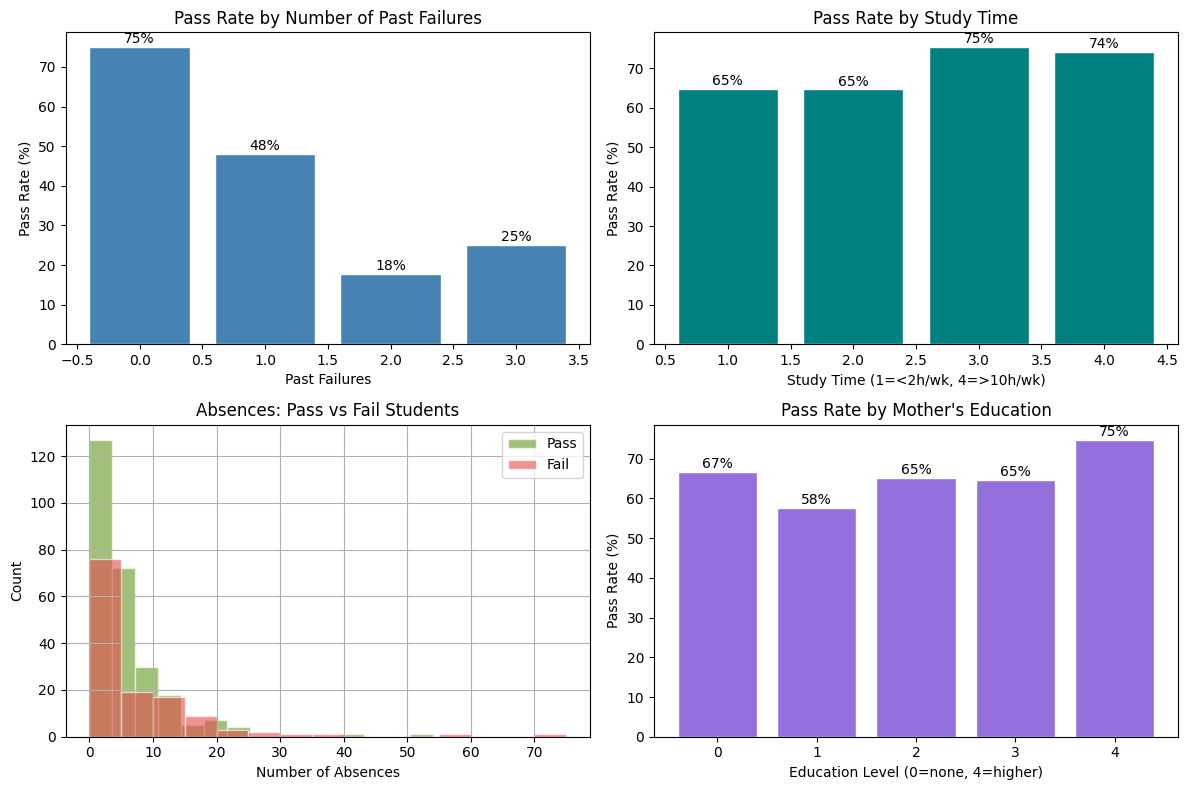

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Past failures vs pass rate
fail_passrate = df.groupby('failures')['pass'].mean() * 100
axes[0,0].bar(fail_passrate.index, fail_passrate.values,
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Pass Rate by Number of Past Failures')
axes[0,0].set_xlabel('Past Failures')
axes[0,0].set_ylabel('Pass Rate (%)')
for i, v in enumerate(fail_passrate.values):
    axes[0,0].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=10)

# 2. Study time vs pass rate
study_passrate = df.groupby('studytime')['pass'].mean() * 100
axes[0,1].bar(study_passrate.index, study_passrate.values,
              color='teal', edgecolor='white')
axes[0,1].set_title('Pass Rate by Study Time')
axes[0,1].set_xlabel('Study Time (1=<2h/wk, 4=>10h/wk)')
axes[0,1].set_ylabel('Pass Rate (%)')
for i, (idx, v) in enumerate(study_passrate.items()):
    axes[0,1].text(idx, v + 1, f'{v:.0f}%', ha='center', fontsize=10)

# 3. Absences distribution: pass vs fail
df[df['pass']==1]['absences'].hist(ax=axes[1,0], bins=15,
    alpha=0.6, color='#639922', label='Pass', edgecolor='white')
df[df['pass']==0]['absences'].hist(ax=axes[1,0], bins=15,
    alpha=0.6, color='#E24B4A', label='Fail', edgecolor='white')
axes[1,0].set_title('Absences: Pass vs Fail Students')
axes[1,0].set_xlabel('Number of Absences')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 4. Mother's education vs pass rate
medu_passrate = df.groupby('Medu')['pass'].mean() * 100
axes[1,1].bar(medu_passrate.index, medu_passrate.values,
              color='mediumpurple', edgecolor='white')
axes[1,1].set_title("Pass Rate by Mother's Education")
axes[1,1].set_xlabel('Education Level (0=none, 4=higher)')
axes[1,1].set_ylabel('Pass Rate (%)')
for i, (idx, v) in enumerate(medu_passrate.items()):
    axes[1,1].text(idx, v + 1, f'{v:.0f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/feature_analysis.png', dpi=150)
plt.show()

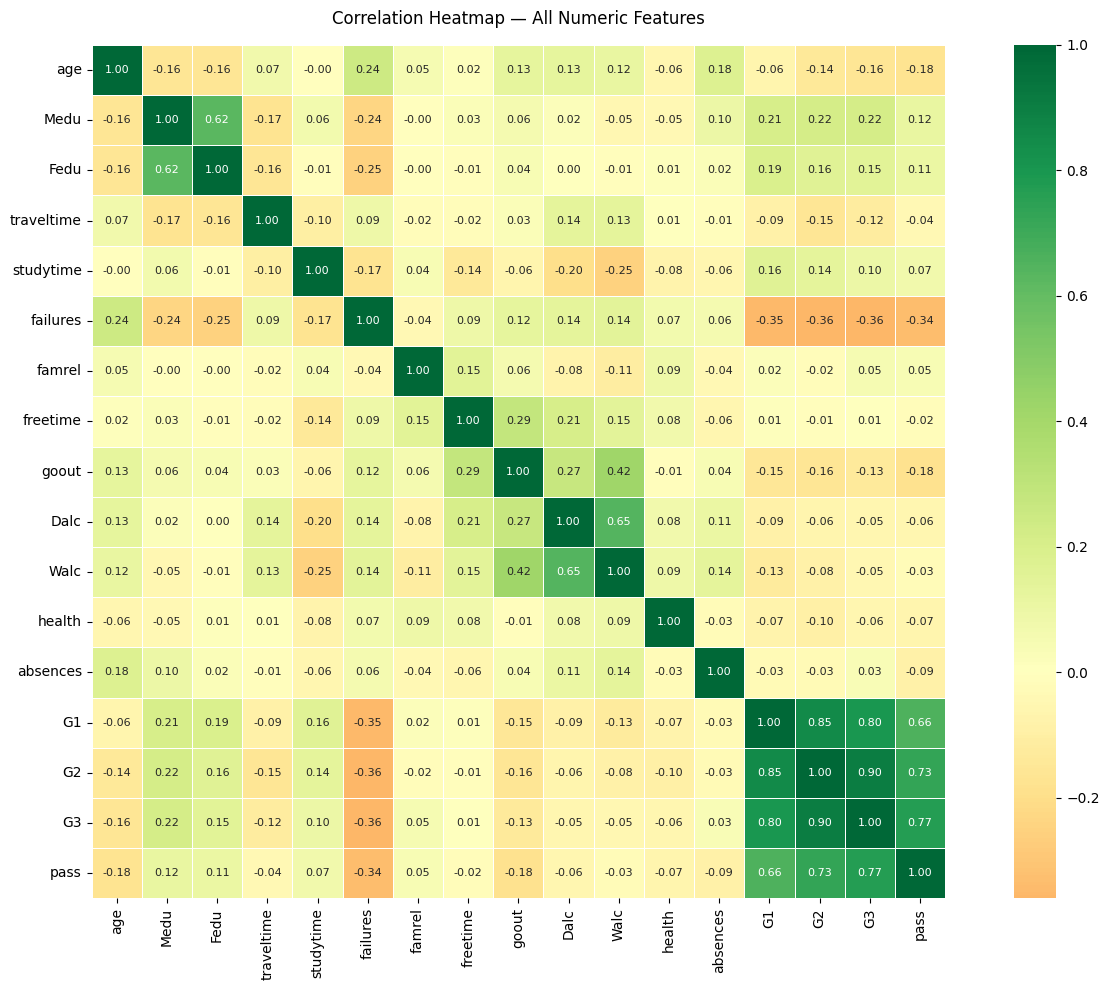

In [9]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Heatmap — All Numeric Features', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

In [10]:
# Clean summary of what matters most
corr_with_pass = df[numeric_cols].corr()['pass'].drop('pass')
corr_with_pass = corr_with_pass.sort_values(key=abs, ascending=False)

print("=== Feature Correlation with Pass/Fail ===\n")
for feature, value in corr_with_pass.items():
    direction = "↑ helps pass" if value > 0 else "↓ hurts pass"
    bar = '█' * int(abs(value) * 20)
    print(f"{feature:<15} {value:+.3f}  {bar}  {direction}")

=== Feature Correlation with Pass/Fail ===

G3              +0.770  ███████████████  ↑ helps pass
G2              +0.725  ██████████████  ↑ helps pass
G1              +0.665  █████████████  ↑ helps pass
failures        -0.338  ██████  ↓ hurts pass
goout           -0.183  ███  ↓ hurts pass
age             -0.180  ███  ↓ hurts pass
Medu            +0.115  ██  ↑ helps pass
Fedu            +0.108  ██  ↑ helps pass
absences        -0.092  █  ↓ hurts pass
studytime       +0.075  █  ↑ helps pass
health          -0.066  █  ↓ hurts pass
Dalc            -0.057  █  ↓ hurts pass
famrel          +0.047    ↑ helps pass
traveltime      -0.044    ↓ hurts pass
Walc            -0.030    ↓ hurts pass
freetime        -0.018    ↓ hurts pass


## EDA Key Findings

1. **Past failures is the strongest predictor** — students with 3+ past
   failures have only a ~20% pass rate vs ~75% for students with none.

2. **Study time matters** — students studying >5 hours/week pass at
   significantly higher rates than those studying <2 hours.

3. **Absences skew higher for failing students** — though the effect
   is weaker than failures and study time.

4. **Mother's education has a meaningful positive effect** — likely a
   proxy for home environment and academic support.

5. **G1 and G2 are extremely highly correlated with G3 (~0.8+)**
   — we will DROP these to avoid data leakage and build a model
   that works with only pre-exam behavioral data.